# EDA — AQI Feature Store

Concise exploratory data analysis: load the `aqi_features` feature group, inspect schema and missingness, visualize distributions and correlations, and perform basic time-series freshness checks. Each code cell is followed by a short markdown summary of findings.

## Imports & setup
We load plotting libraries and `hopsworks` client. Ensure `HOPSWORKS_HOST` and `HOPSWORKS_API_KEY` are available in your environment or `.env`.

In [2]:
# Cell 1: Imports and plotting setup
import os
from dotenv import load_dotenv
import pandas as pd
import hopsworks
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

load_dotenv()
sns.set(style="whitegrid")

d:\Projects\Intern Project\AQI_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data
This cell reads the `aqi_features` offline feature group, parses `timestamp`, and sorts the dataset. `head()` shows the first rows and column names to verify the schema.

In [3]:
# Cell 2: Load data from Hopsworks feature group
project = hopsworks.login(host=os.getenv('HOPSWORKS_HOST', 'eu-west.cloud.hopsworks.ai'),
                             api_key_value=os.getenv('HOPSWORKS_API_KEY'))
fs = project.get_feature_store()
fg = fs.get_feature_group(name='aqi_features', version=1)
df = fg.read(online=False)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values('timestamp').reset_index(drop=True)

print('Loaded rows, columns:', df.shape)
df.head()

2026-05-22 16:46:39,473 INFO: Initializing external client
2026-05-22 16:46:39,473 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443
2026-05-22 16:46:42,030 INFO: Python Engine initialized.

Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/31957
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (1.91s) 
Loaded rows, columns: (2400, 48)


,timestamp,pm25,pm10,o3,no2,so2,co,temperature,humidity,wind_speed,...,fc_o3_48h,fc_dust_48h,fc_uvi_48h,fc_pm25_72h,fc_co_72h,fc_no2_72h,fc_so2_72h,fc_o3_72h,fc_dust_72h,fc_uvi_72h
0,2026-01-29 00:00:00+00:00,28.6,32.0,34.0,34.4,12.9,436.0,15.1,52.0,8.3,...,33.0,0.0,0.0,33.6,407.0,28.6,11.0,26.0,0.0,0.0
1,2026-01-29 01:00:00+00:00,27.0,30.7,29.0,37.1,13.1,655.0,14.5,53.0,8.3,...,27.0,0.0,0.0,33.9,673.0,34.2,12.3,20.0,0.0,0.0
2,2026-01-29 02:00:00+00:00,27.9,32.1,24.0,40.5,13.5,991.0,13.9,55.0,8.6,...,20.0,0.0,0.0,36.3,1084.0,41.5,14.3,13.0,0.0,0.0
3,2026-01-29 03:00:00+00:00,32.0,36.4,28.0,40.1,14.0,1196.0,13.9,56.0,8.8,...,25.0,0.0,0.0,43.5,1353.0,44.1,16.6,16.0,0.0,0.0
4,2026-01-29 04:00:00+00:00,32.0,35.5,49.0,32.3,14.7,1140.0,15.4,51.0,8.7,...,52.0,0.0,0.0,41.0,1331.0,37.8,19.8,39.0,0.0,0.0


## Data summary
Check dtypes to confirm numeric vs categorical features, inspect missingness to decide imputation, and review `describe()` for scale and spread of numeric columns such as `aqi`, `pm25`, `pm10`.

In [4]:
# Cell 3: Data types, missing values, and basic stats
display(df.dtypes)
print('--- Missing values per column ---')
display(df.isnull().sum()[df.isnull().sum() > 0])
print('\n--- Descriptive stats (numeric) ---')
display(df.describe().round(3))

timestamp           datetime64[us, UTC]
pm25                            float64
pm10                            float64
o3                              float64
no2                             float64
so2                             float64
co                              float64
temperature                     float64
humidity                        float64
wind_speed                      float64
aqi                             float64
hour_of_day                       int32
day_of_week                       int32
month                             int32
hour_sin                        float64
hour_cos                        float64
dow_sin                         float64
dow_cos                         float64
aqi_lag_1h                      float64
aqi_lag_3h                      float64
aqi_lag_6h                      float64
aqi_lag_12h                     float64
aqi_lag_24h                     float64
rolling_mean_6h                 float64
rolling_mean_24h                float64


--- Missing values per column ---


temperature         1
humidity            1
wind_speed          1
aqi_lag_1h          1
aqi_lag_3h          3
aqi_lag_6h          6
aqi_lag_12h        12
aqi_lag_24h        24
rolling_std_6h      1
rolling_std_24h     1
fc_pm25_24h         1
fc_co_24h           1
fc_no2_24h          1
fc_so2_24h          1
fc_o3_24h           1
fc_dust_24h         1
fc_uvi_24h          1
fc_pm25_48h         1
fc_co_48h           1
fc_no2_48h          1
fc_so2_48h          1
fc_o3_48h           1
fc_dust_48h         1
fc_uvi_48h          1
fc_pm25_72h         1
fc_co_72h           1
fc_no2_72h          1
fc_so2_72h          1
fc_o3_72h           1
fc_dust_72h         1
fc_uvi_72h          1
dtype: int64


--- Descriptive stats (numeric) ---


,pm25,pm10,o3,no2,so2,co,temperature,humidity,wind_speed,aqi,...,fc_o3_48h,fc_dust_48h,fc_uvi_48h,fc_pm25_72h,fc_co_72h,fc_no2_72h,fc_so2_72h,fc_o3_72h,fc_dust_72h,fc_uvi_72h
count,2400.000,2400.000,2400.000,2400.000,2400.000,2400.000,2399.000,2399.000,2399.000,2400.000,...,2399.000,2399.000,2399.000,2399.000,2399.000,2399.000,2399.000,2399.000,2399.000,2399.000
mean,26.930,52.700,81.863,20.303,14.511,492.553,25.547,67.020,10.089,82.354,...,82.678,8.803,0.245,27.527,482.047,19.740,14.245,83.010,11.239,0.264
std,11.036,30.063,39.710,16.034,6.642,304.117,3.901,19.822,3.935,23.990,...,38.686,33.736,0.756,11.134,294.879,15.391,6.479,38.381,40.740,0.773
min,3.500,3.700,0.000,0.000,3.500,116.000,13.900,10.000,0.200,14.583,...,0.000,0.000,0.000,3.500,116.000,0.000,4.492,0.000,0.000,0.000
25%,19.300,34.100,51.000,8.200,9.900,280.000,23.000,53.000,7.400,66.000,...,53.000,0.000,0.000,20.100,281.000,8.360,9.700,54.000,0.000,0.000
50%,24.900,45.100,75.000,16.300,13.300,407.000,25.400,68.000,9.700,77.918,...,77.708,0.000,0.000,25.571,399.000,15.400,13.000,79.000,0.000,0.000
75%,32.400,61.700,112.000,27.900,17.400,602.000,28.100,84.000,12.800,93.691,...,110.500,0.000,0.000,32.500,580.500,27.000,17.000,110.854,0.000,0.000
max,79.900,258.000,203.000,116.600,47.200,2589.000,37.100,100.000,23.400,163.599,...,203.000,324.458,4.696,79.900,2589.000,116.600,47.200,203.000,338.167,4.696


## Distributions
Histogram + KDE plots reveal skewness and outliers. If a variable is heavily skewed consider log or quantile transforms before modeling.

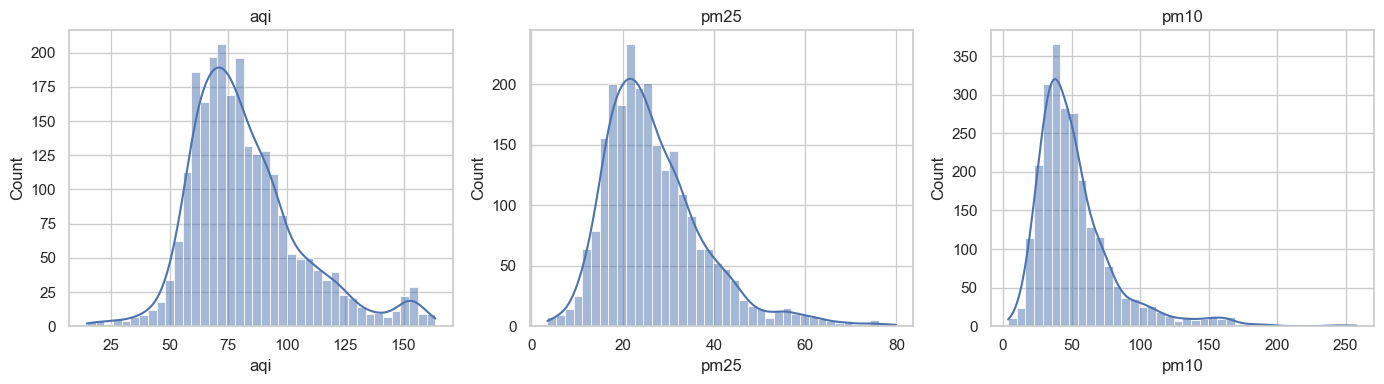

In [5]:
# Cell 4: Distribution plots for core variables
cols = ['aqi', 'pm25', 'pm10']
plt.figure(figsize=(14,4))
for i, c in enumerate(cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[c].dropna(), kde=True, bins=40)
    plt.title(c)
plt.tight_layout()

## Correlations
Use the heatmap to identify predictors strongly correlated with `aqi` and potential multicollinearity among features (e.g., `pm25` vs `pm10`).

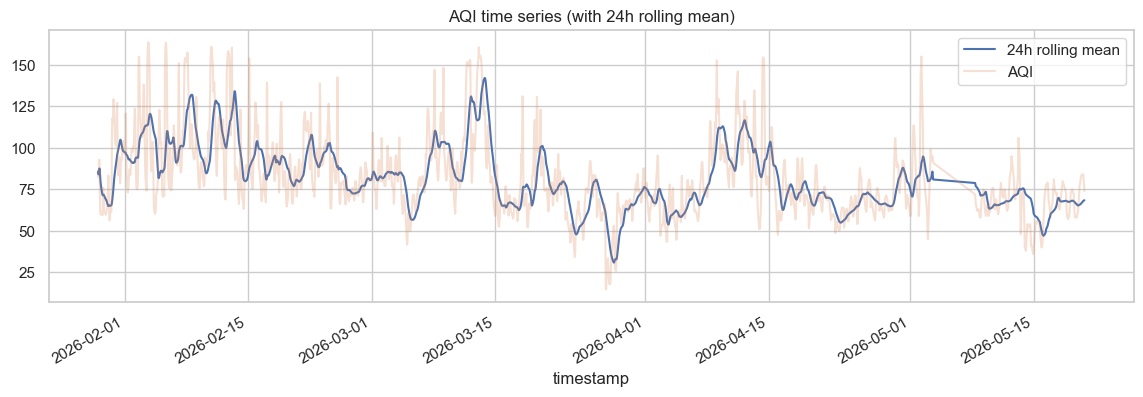

Latest data point: 2026-05-20 17:00:00+00:00 (UTC) — freshness: 42.8 hours

Recent rows:


,timestamp,aqi,pm25,pm10
2390,2026-05-19 15:00:00+00:00,58.0,15.4,32.7
2391,2026-05-19 18:00:00+00:00,59.0,15.7,31.2
2392,2026-05-19 20:00:00+00:00,58.0,15.6,32.7
2393,2026-05-19 22:00:00+00:00,60.0,16.4,36.7
2394,2026-05-20 00:00:00+00:00,62.0,17.5,40.7
2395,2026-05-20 04:00:00+00:00,77.0,24.6,65.9
2396,2026-05-20 08:00:00+00:00,83.0,27.1,74.3
2397,2026-05-20 11:00:00+00:00,84.0,28.0,75.9
2398,2026-05-20 14:00:00+00:00,84.0,27.6,66.8
2399,2026-05-20 17:00:00+00:00,74.0,22.9,49.7


In [6]:
# Cell 6: Time series checks — AQI over time and freshness
plt.figure(figsize=(14,4))
df_plot = df.set_index('timestamp')
df_plot['aqi'].rolling(window=24, min_periods=1).mean().plot(label='24h rolling mean')
df_plot['aqi'].plot(alpha=0.25, label='AQI')
plt.legend()
plt.title('AQI time series (with 24h rolling mean)')
plt.show()

# Freshness and gap checks
now_utc = pd.Timestamp.now(tz='UTC')
latest = df['timestamp'].max()
gap_hours = (now_utc - latest).total_seconds() / 3600
print(f"Latest data point: {latest} (UTC) — freshness: {gap_hours:.1f} hours")
print('\nRecent rows:')
display(df[['timestamp','aqi','pm25','pm10']].tail(10))

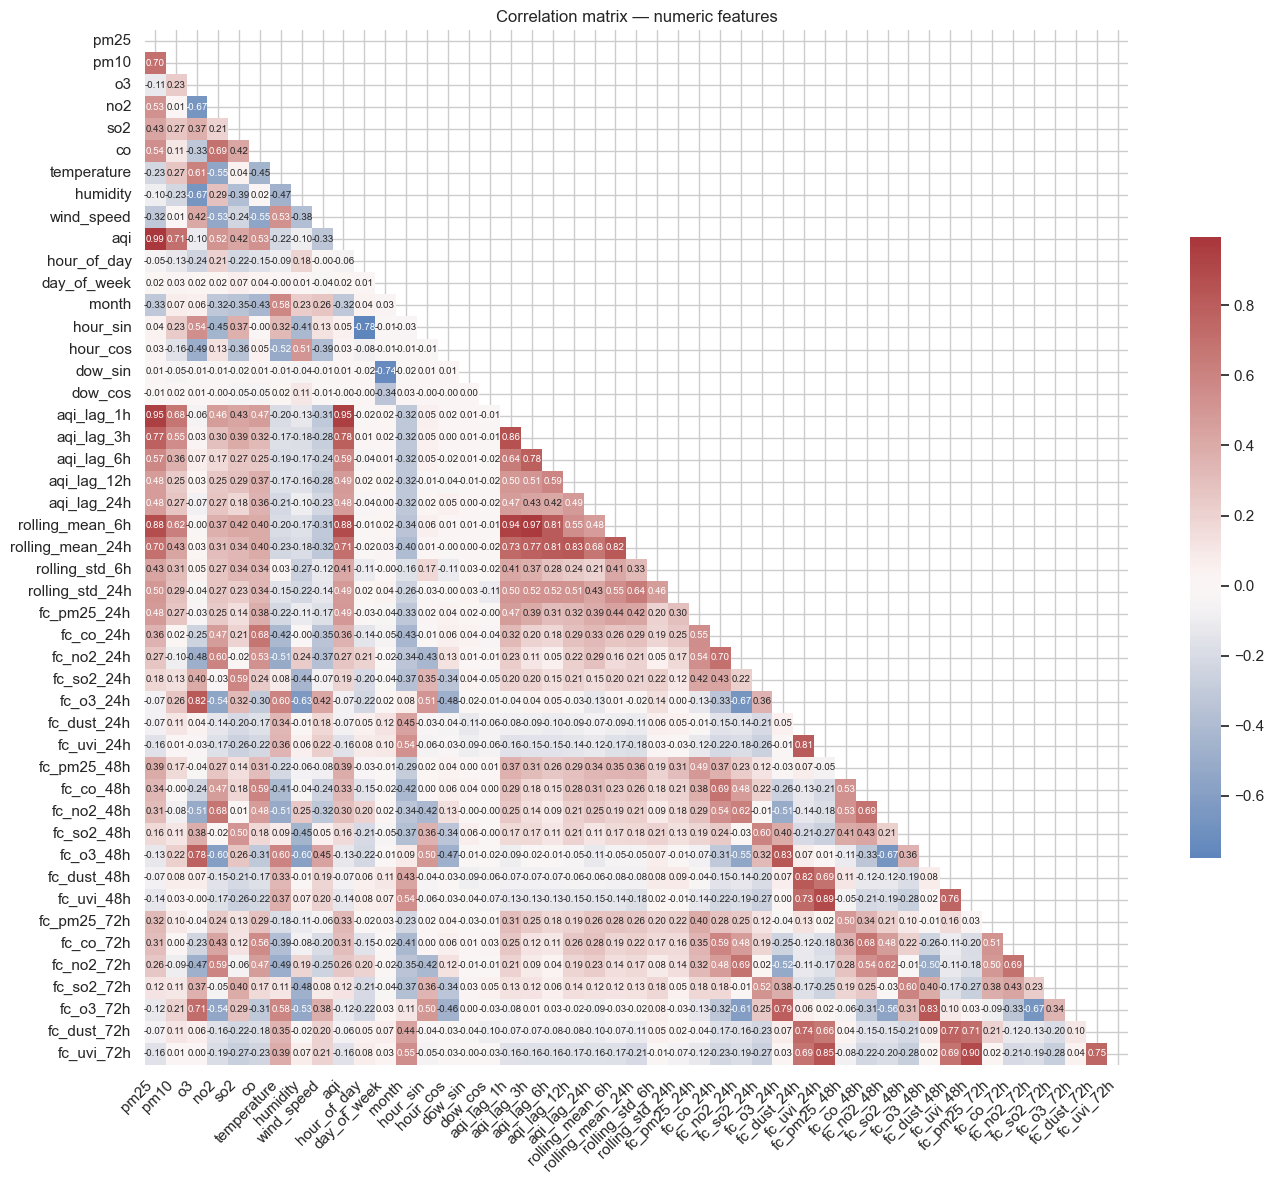

In [7]:
# Cell 5: Correlation matrix and heatmap for numeric features
num = df.select_dtypes(include=['number'])
corr = num.corr()
plt.figure(figsize=(14,12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='vlag', center=0, annot_kws={'size':7}, cbar_kws={'shrink':0.6})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title('Correlation matrix — numeric features')
plt.tight_layout()
plt.show()

## Time series
Plotting the series and a rolling mean helps reveal trends and seasonality; freshness check verifies pipelines are running and data is up-to-date.

In [8]:
# Cell 7: Quick checks — duplicates, coverage, and next steps
dupes = df[df.duplicated(subset=['timestamp'], keep=False)]
print('Duplicate timestamp rows:', len(dupes))
na_counts = df.isnull().sum()
print('Top NaN columns:\n', na_counts[na_counts>0].sort_values(ascending=False).head(10))
print('\nSuggested next steps:' )
print('- Impute or remove columns with high missingness')
print('- Transform skewed predictors (log/quantile) if needed')
print('- Select features correlated with `aqi` for modeling')

Duplicate timestamp rows: 0
Top NaN columns:
 aqi_lag_24h    24
aqi_lag_12h    12
aqi_lag_6h      6
aqi_lag_3h      3
temperature     1
fc_pm25_72h     1
fc_so2_48h      1
fc_o3_48h       1
fc_dust_48h     1
fc_uvi_48h      1
dtype: int64

Suggested next steps:
- Impute or remove columns with high missingness
- Transform skewed predictors (log/quantile) if needed
- Select features correlated with `aqi` for modeling


## Summary
Basic EDA complete — data loaded, types and missingness inspected, distributions and correlations visualized, and time-series freshness checked. Use these outputs to guide imputation, feature selection, and model preparation.